Q1. Answer:

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('C:/Users/rabin/sci-comp-ii-fall24/data/US_births_2000-2014_SSA.csv')
df

,year,month,date_of_month,day_of_week,births
0,2000,1,1,6,9083
1,2000,1,2,7,8006
2,2000,1,3,1,11363
3,2000,1,4,2,13032
4,2000,1,5,3,12558
...,...,...,...,...,...
5474,2014,12,27,6,8656
5475,2014,12,28,7,7724
5476,2014,12,29,1,12811
5477,2014,12,30,2,13634


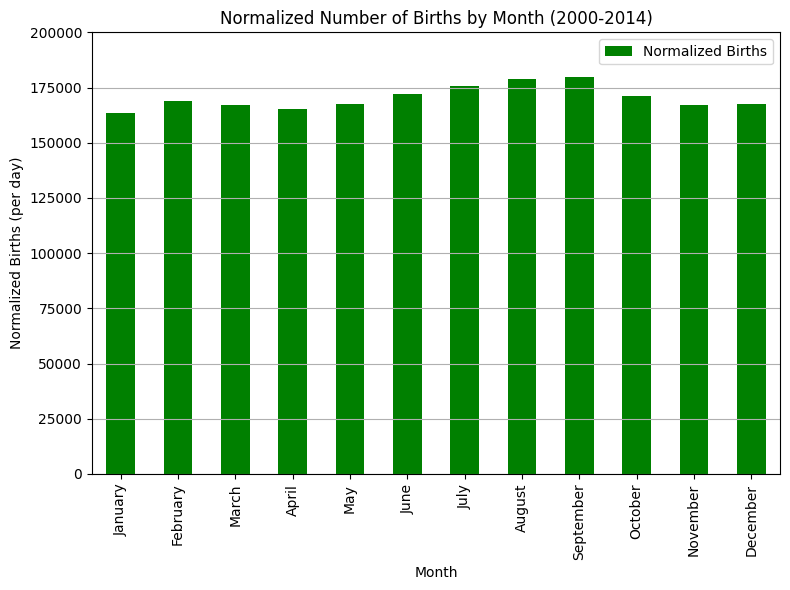

In [163]:
monthly_births = df.groupby('month')['births'].sum()

days_in_month = [31, 28, 31, 30, 31, 30, 
                 31, 31, 30, 31, 30, 31]
normalized_births = monthly_births / days_in_month

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(8, 6))

normalized_births.plot(kind='bar', color='Green', label='Normalized Births')

plt.title('Normalized Number of Births by Month (2000-2014)')
plt.xlabel('Month')
plt.ylabel('Normalized Births (per day)')
plt.xticks(ticks=range(12), labels=month_names)
plt.grid(axis='y')
plt.yticks(ticks=plt.yticks()[0])  
plt.tight_layout()
plt.legend()
plt.show()



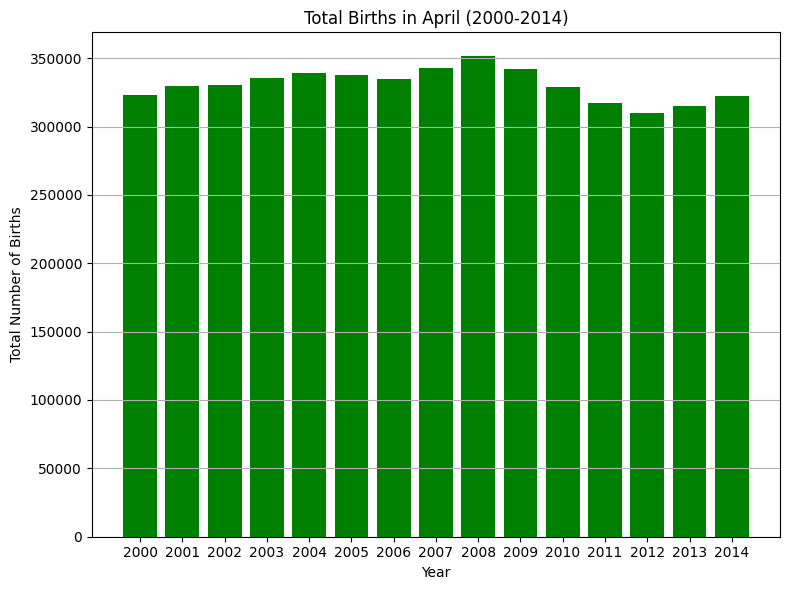

In [164]:
April_births = df[df['month'] == 4]
total_births_April = April_births.groupby('year')['births'].sum().reset_index()


plt.figure(figsize=(8, 6))
plt.bar(total_births_April['year'], total_births_April['births'], color='Green')
plt.title('Total Births in April (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Total Number of Births')
plt.xticks(total_births_April['year'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

I wanted to discover if the low number of births in April following normalization is a constant, universal truth. It's interesting that this was affected more severely, following the US Great Recession that started in 2008. 

Q2. Answer: 

In [144]:
pip install pandas-datareader


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\rabin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


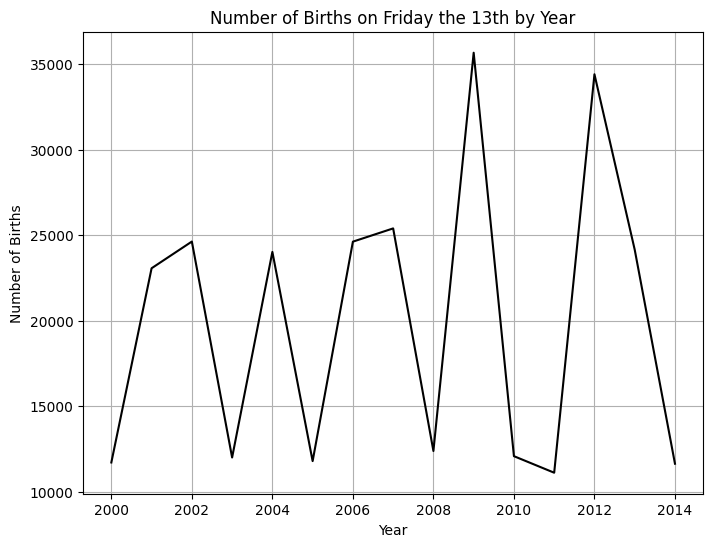

In [165]:
from pandas.tseries.holiday import get_calendar, Holiday, HolidayCalendarFactory, FR
from pandas.tseries.holiday import USFederalHolidayCalendar
from datetime import datetime
import numpy as np

fri_thirteenth_sel = (df['date_of_month'] == 13) & (df['day_of_week'] == 5)
births_on_fri_13 = df[fri_thirteenth_sel]['births'].groupby(df['year']).sum()

plt.figure(figsize=(8, 6))
plt.plot(births_on_fri_13.index, births_on_fri_13.values, linestyle='-', color='black')
plt.title('Number of Births on Friday the 13th by Year')
plt.xlabel('Year')
plt.ylabel('Number of Births')
plt.grid(True)
plt.show()

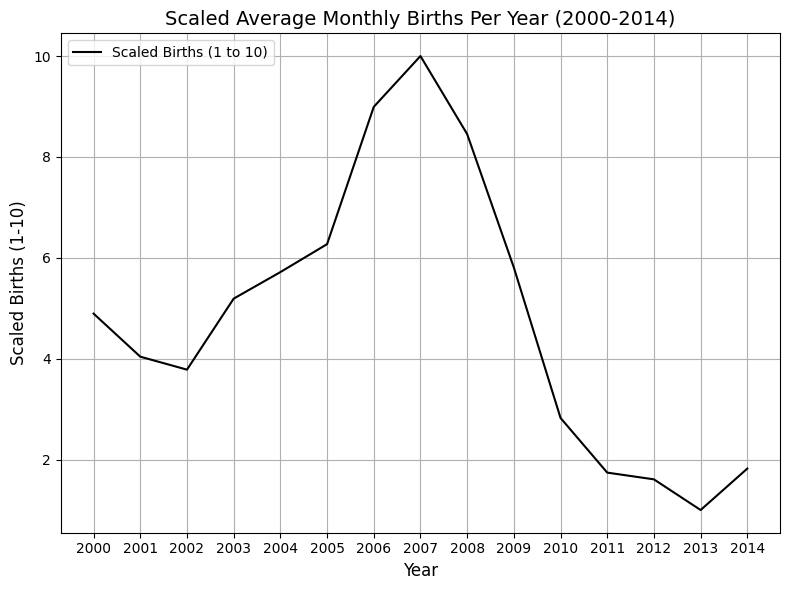

In [167]:
monthly_births = df.groupby(['year', 'month'])['births'].sum().reset_index()
monthly_births_pivot = monthly_births.pivot(index='year', columns='month', values='births')
monthly_births_pivot['average_births'] = monthly_births_pivot.mean(axis=1)

min_births = monthly_births_pivot['average_births'].min()
max_births = monthly_births_pivot['average_births'].max()

monthly_births_pivot['scaled_births'] = 1 + ((monthly_births_pivot['average_births'] - min_births) * (10 - 1)) / (max_births - min_births)

plt.figure(figsize=(8, 6))
plt.plot(monthly_births_pivot.index, monthly_births_pivot['scaled_births'], color='black', label='Scaled Births (1 to 10)')
plt.title('Scaled Average Monthly Births Per Year (2000-2014)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Scaled Births (1-10)', fontsize=12)
plt.xticks(monthly_births_pivot.index)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()



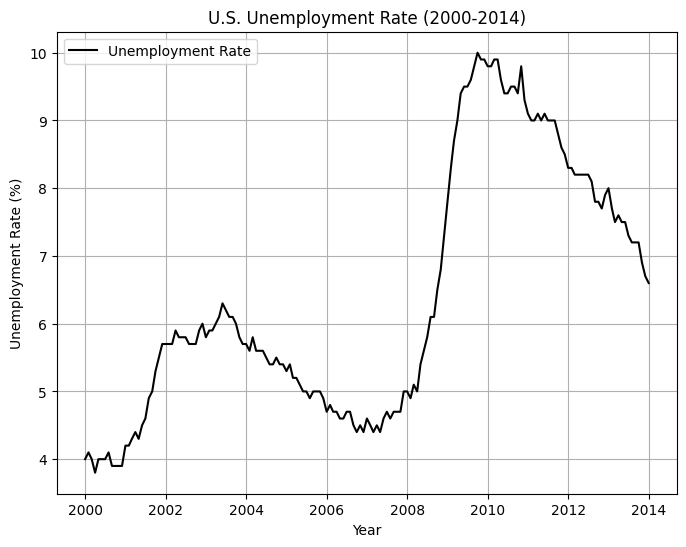

In [169]:

import pandas_datareader.data as web

start = '2000'
end = '2014'

plt.figure(figsize=(8, 6))

unemployment_data = web.DataReader('UNRATE', 'fred', start, end)
 
plt.plot(unemployment_data.index, unemployment_data['UNRATE'], label='Unemployment Rate', color='black')
plt.title('U.S. Unemployment Rate (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')  
plt.legend()
plt.grid()
plt.show()


C:\Users\rabin\AppData\Local\Temp\ipykernel_25360\2936733143.py:7: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  unemployment_yearly = unemployment_data.resample('A').mean()


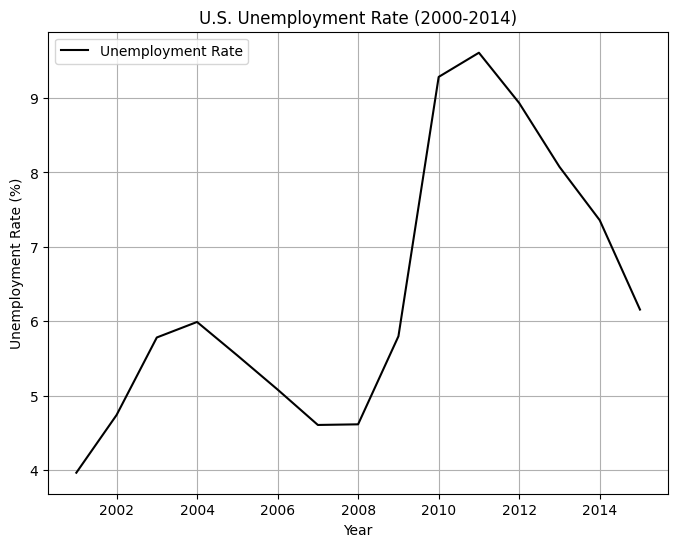

In [170]:
start = '2000-01-01'
end = '2014-12-31'

plt.figure(figsize=(8, 6))

unemployment_data = web.DataReader('UNRATE', 'fred', start, end)
unemployment_yearly = unemployment_data.resample('A').mean()

plt.plot(unemployment_yearly.index, unemployment_yearly['UNRATE'], label='Unemployment Rate', color='black')
plt.title('U.S. Unemployment Rate (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')  
plt.legend()
plt.grid()
plt.show()


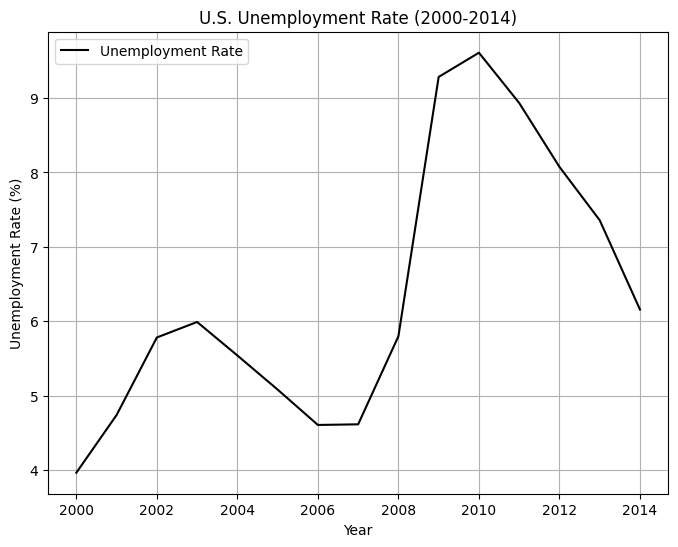

In [171]:

unemployment_yearly.index = unemployment_yearly.index.year

plt.figure(figsize=(8, 6))

plt.plot(unemployment_yearly.index, unemployment_yearly['UNRATE'], label='Unemployment Rate', color='black')
plt.title('U.S. Unemployment Rate (2000-2014)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')  
plt.legend()
plt.grid()
plt.show()



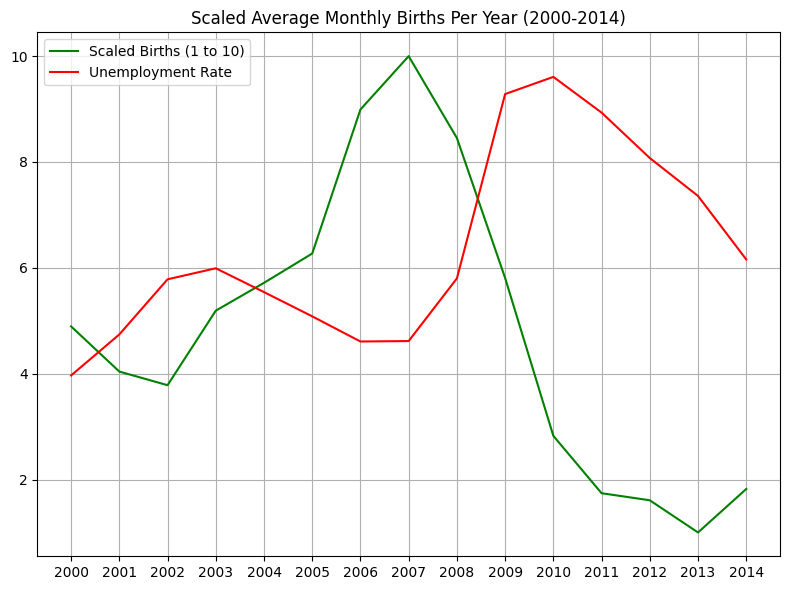

In [172]:

plt.figure(figsize=(8, 6))

plt.plot(monthly_births_pivot.index, monthly_births_pivot['scaled_births'], color='Green', label='Scaled Births (1 to 10)')
plt.plot(unemployment_yearly.index, unemployment_yearly['UNRATE'], label='Unemployment Rate', color='Red')
plt.title('Scaled Average Monthly Births Per Year (2000-2014)', fontsize=12)

plt.xticks(monthly_births_pivot.index)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

The graph shows the relationship between birth and unemployment. Birth rates are low when unemployment is high and vice versa.

Q3. Answer:

In [154]:
DataCr = pd.read_csv('C:/Users/rabin/sci-comp-ii-fall24/homework/hw_birth-and-movie/data/tmdb_5000_credits.csv')
DataM = pd.read_csv('C:/Users/rabin/sci-comp-ii-fall24/homework/hw_birth-and-movie/data/tmdb_5000_movies.csv')

In [155]:
print(DataCr.head())

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4  [{"credit_id": "52fe479ac3a36847f813eaa3",

In [156]:
print(DataM.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

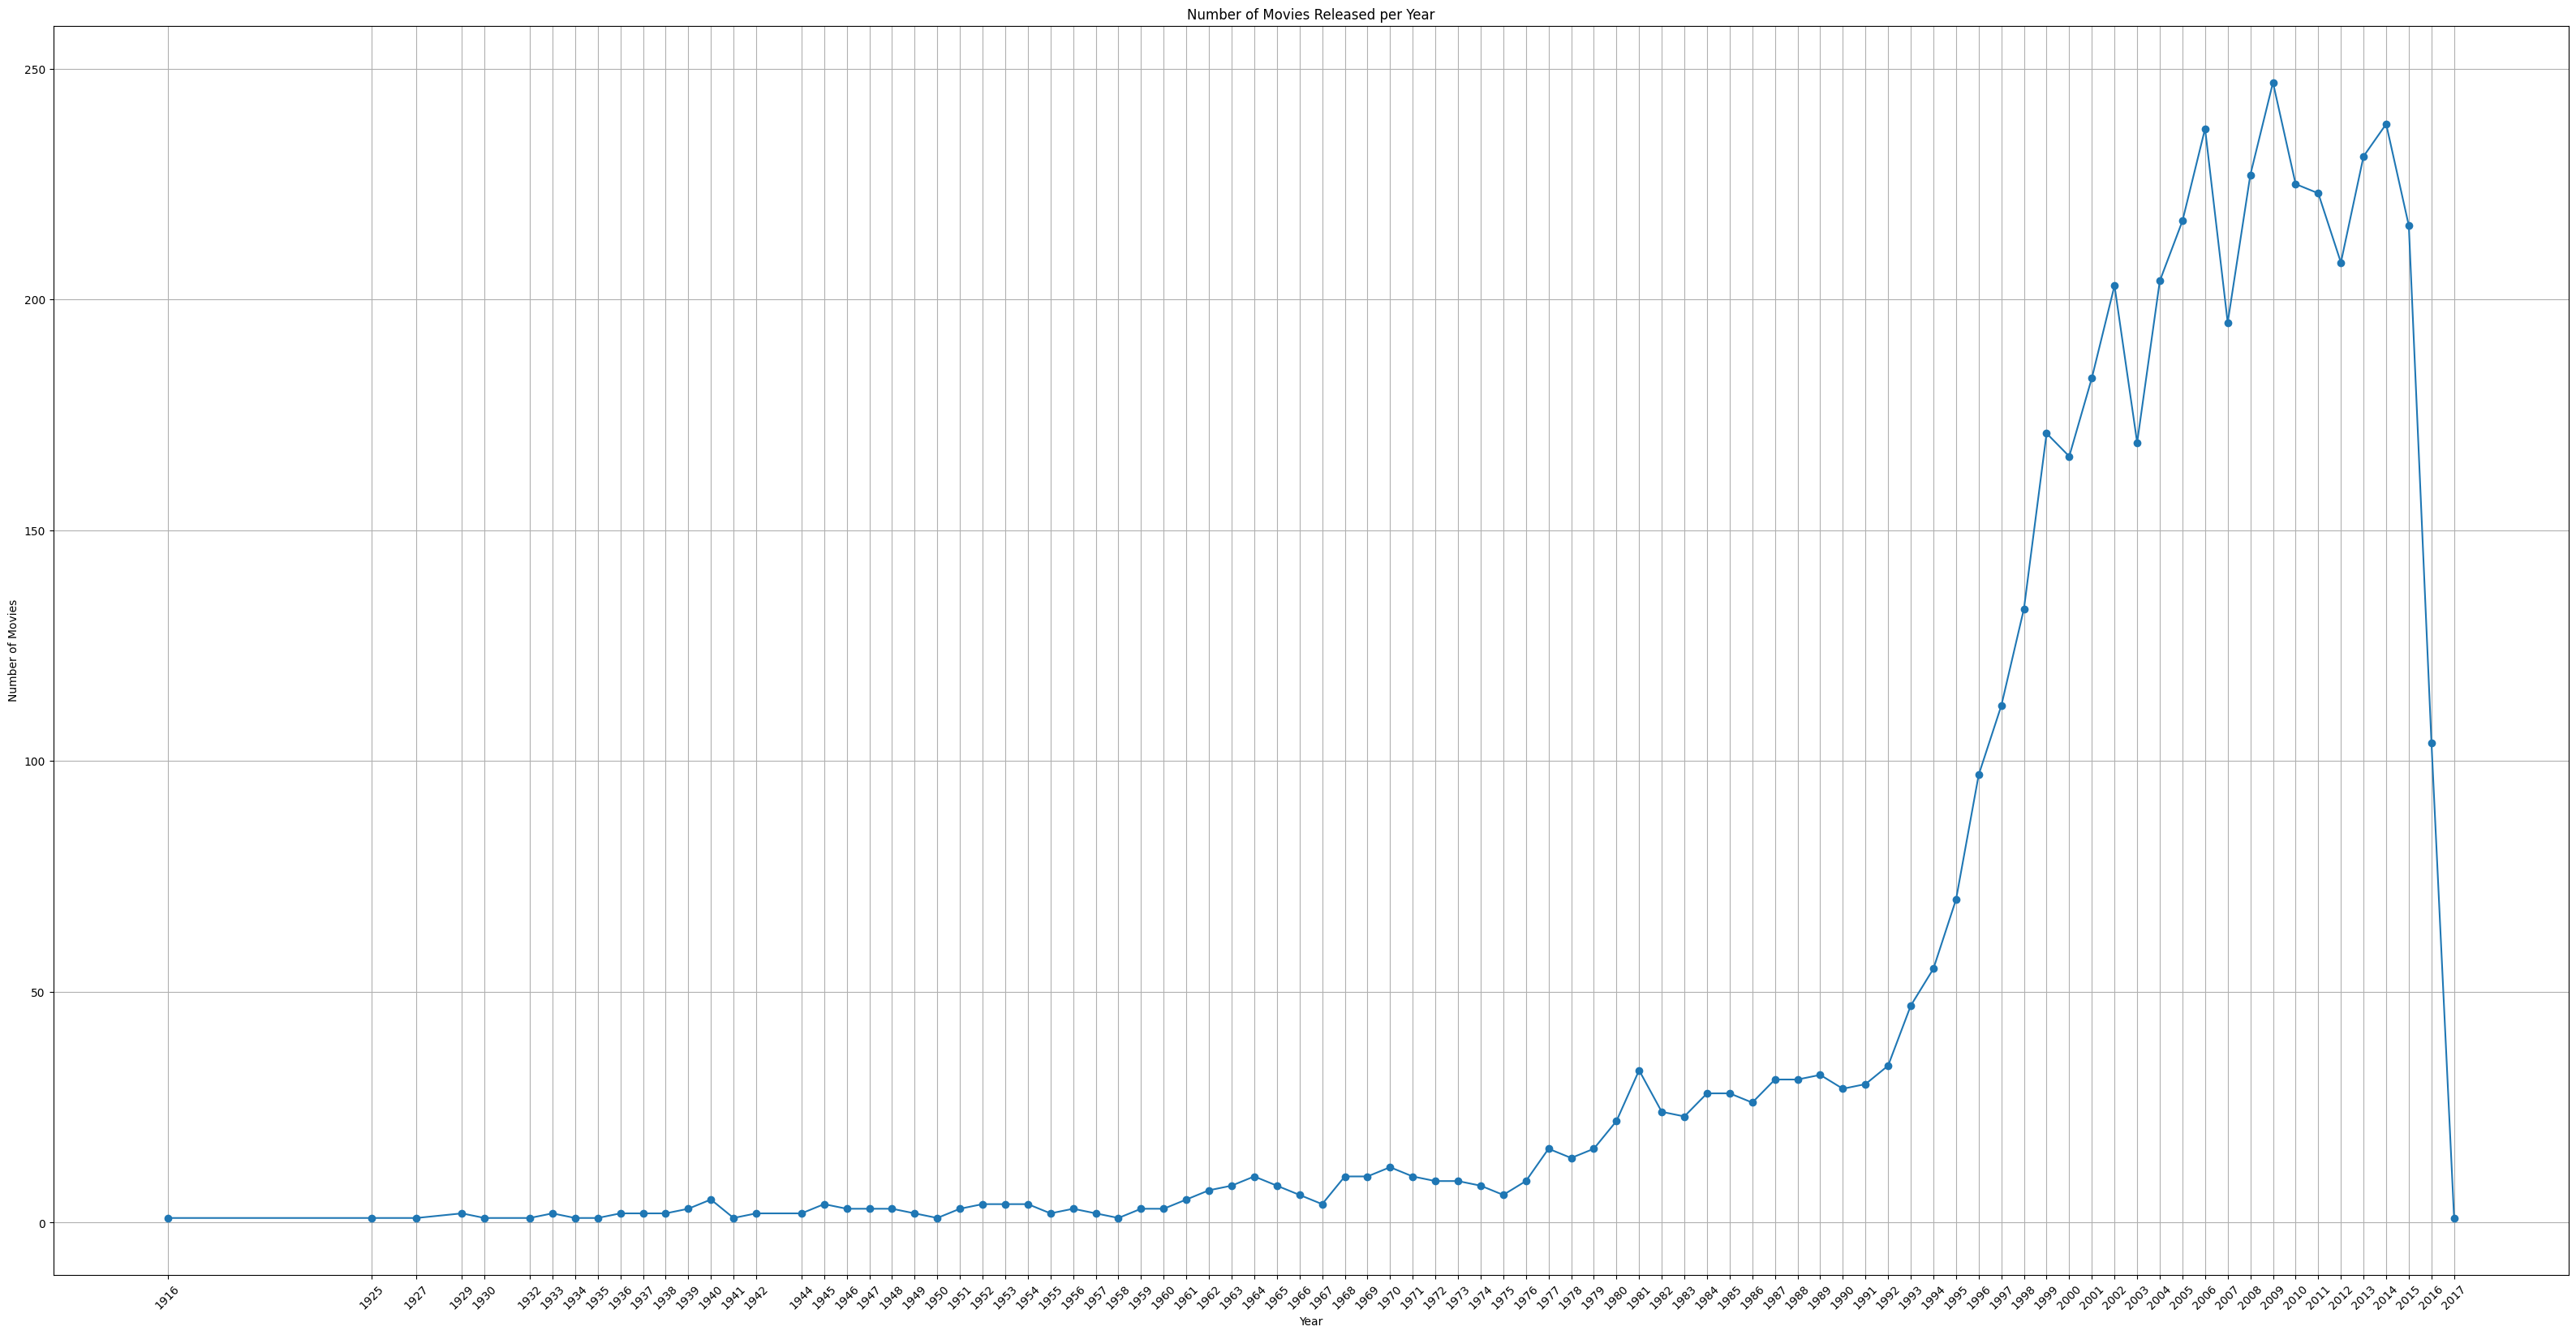

In [157]:
DataM['release_date'] = pd.to_datetime(DataM['release_date'], errors='coerce')
DataM['release_year'] = DataM['release_date'].dt.year
release_trends = DataM['release_year'].value_counts().sort_index()


plt.figure(figsize=(40, 20))
plt.plot(release_trends.index, release_trends.values, marker='o')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xticks(release_trends.index, rotation=45)
plt.grid()
plt.show()


Movie releases increased after VHS and DVD became popular in the 1990s because they created new revenue streams, met consumer demand for home viewing, lowered production costs, and expanded distribution options.